In [1]:
##################################################################
# # ! Two methods to approximate a sphere with a polyhedron:
# (1) Recursive subdivision of an icosahedron
# (2) Triangulated regular geographic grid
##################################################################
# %%
# # ! Setup
import numpy as np
from datetime import datetime
import pyvista as pv
pv.set_jupyter_backend('static')
from gravity_forward_numba import spherical_edge_length_range

In [2]:
# # ! Start time
print("="*80)
print(f"Start time: [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]")
print("="*80)

Start time: [2026-04-25 18:20:38]


In [3]:
# # ! Recursive subdivision of an icosahedron
# True volume and surface area of unit sphere
vol_true  = 4 * np.pi / 3
area_true = 4 * np.pi
nsub_max = 10
NSUBs = np.arange(nsub_max + 1)
# ------------------------------------------------------------------
# (1) Recursive subdivision of an icosahedron
# ------------------------------------------------------------------
print("\n" + "="*90)
print("Recursive subdivision of an icosahedron")
print(f"{'nsub':<6} {'NV':>12} {'NT':>12} "
      f"{'Vol_err':>10} {'Area_err':>10} "
      f"{'Min_psi (arcmin)':>18} {'Max_psi (arcmin)':>18}")
print("-" * 90)
for nsub in NSUBs:
    mesh = pv.Icosphere(radius=1.0, nsub=nsub)
    verts = mesh.points
    faces = mesh.regular_faces
    Nv = verts.shape[0]
    Nt = faces.shape[0]
    vol_err = np.abs((mesh.volume-vol_true) / vol_true)
    area_err = np.abs((mesh.area-area_true) / area_true)
    min_psi, max_psi = spherical_edge_length_range(verts, faces)
    min_psi_arcmin = 60.0 * np.rad2deg(min_psi)
    max_psi_arcmin = 60.0 * np.rad2deg(max_psi)
    print(f"{nsub:<6} {Nv:>12} {Nt:>12} "
          f"{vol_err:>10.2e} {area_err:>10.2e} "
          f"{min_psi_arcmin:>18.2e} {max_psi_arcmin:>18.2e}")


Recursive subdivision of an icosahedron
nsub             NV           NT    Vol_err   Area_err   Min_psi (arcmin)   Max_psi (arcmin)
------------------------------------------------------------------------------------------
0                12           20   3.95e-01   2.38e-01           3.81e+03           3.81e+03
1                42           80   1.27e-01   7.17e-02           1.90e+03           2.16e+03
2               162          320   3.38e-02   1.89e-02           8.73e+02           1.12e+03
3               642         1280   8.62e-03   4.79e-03           4.11e+02           5.67e+02
4              2562         5120   2.17e-03   1.20e-03           1.99e+02           2.84e+02
5             10242        20480   5.42e-04   3.01e-04           9.78e+01           1.42e+02
6             40962        81920   1.36e-04   7.52e-05           4.85e+01           7.11e+01
7            163842       327680   3.39e-05   1.88e-05           2.41e+01           3.55e+01
8            655362      131072

In [4]:
# # ! Triangulated regular geographic grid
# ------------------------------------------------------------------
# (2) Triangulated regular geographic grid
# ------------------------------------------------------------------
print("\n" + "="*90)
print("Triangulated Regular Geographic Grid")
print(f"{'level':<6} {'NV':>12} {'NT':>12} "
      f"{'Vol_err':>10} {'Area_err':>10} "
      f"{'Min_psi (arcmin)':>18} {'Max_psi (arcmin)':>18}")
print("-" * 90)
Lon_Res = 5 * (2 ** NSUBs)
Lat_Res = (2 ** (NSUBs + 1)) + 2
for i, nsub in enumerate(NSUBs):
    theta_res = Lon_Res[i]
    phi_res   = Lat_Res[i]
    mesh = pv.Sphere(radius=1.0, theta_resolution=theta_res, phi_resolution=phi_res)
    verts = mesh.points
    faces = mesh.regular_faces
    Nv = verts.shape[0]
    Nt = faces.shape[0]
    vol_err = np.abs((mesh.volume-vol_true) / vol_true)
    area_err = np.abs((mesh.area-area_true) / area_true)
    min_psi, max_psi = spherical_edge_length_range(verts, faces)
    min_psi_arcmin = 60.0 * np.rad2deg(min_psi)
    max_psi_arcmin = 60.0 * np.rad2deg(max_psi)
    print(f"{nsub:<6} {Nv:>12} {Nt:>12} "
          f"{vol_err:>10.2e} {area_err:>10.2e} "
          f"{min_psi_arcmin:>18.2e} {max_psi_arcmin:>18.2e}")


Triangulated Regular Geographic Grid
level            NV           NT    Vol_err   Area_err   Min_psi (arcmin)   Max_psi (arcmin)
------------------------------------------------------------------------------------------
0                12           20   4.32e-01   2.46e-01           3.60e+03           5.46e+03
1                42           80   1.54e-01   8.02e-02           1.26e+03           3.03e+03
2               162          320   4.60e-02   2.33e-02           3.68e+02           1.61e+03
3               642         1280   1.26e-02   6.31e-03           9.91e+01           8.33e+02
4              2562         5120   3.29e-03   1.65e-03           2.57e+01           4.24e+02
5             10242        20480   8.41e-04   4.20e-04           6.52e+00           2.14e+02
6             40962        81920   2.13e-04   1.06e-04           1.64e+00           1.08e+02
7            163842       327680   5.34e-05   2.67e-05           4.13e-01           5.39e+01
8            655362      1310720  

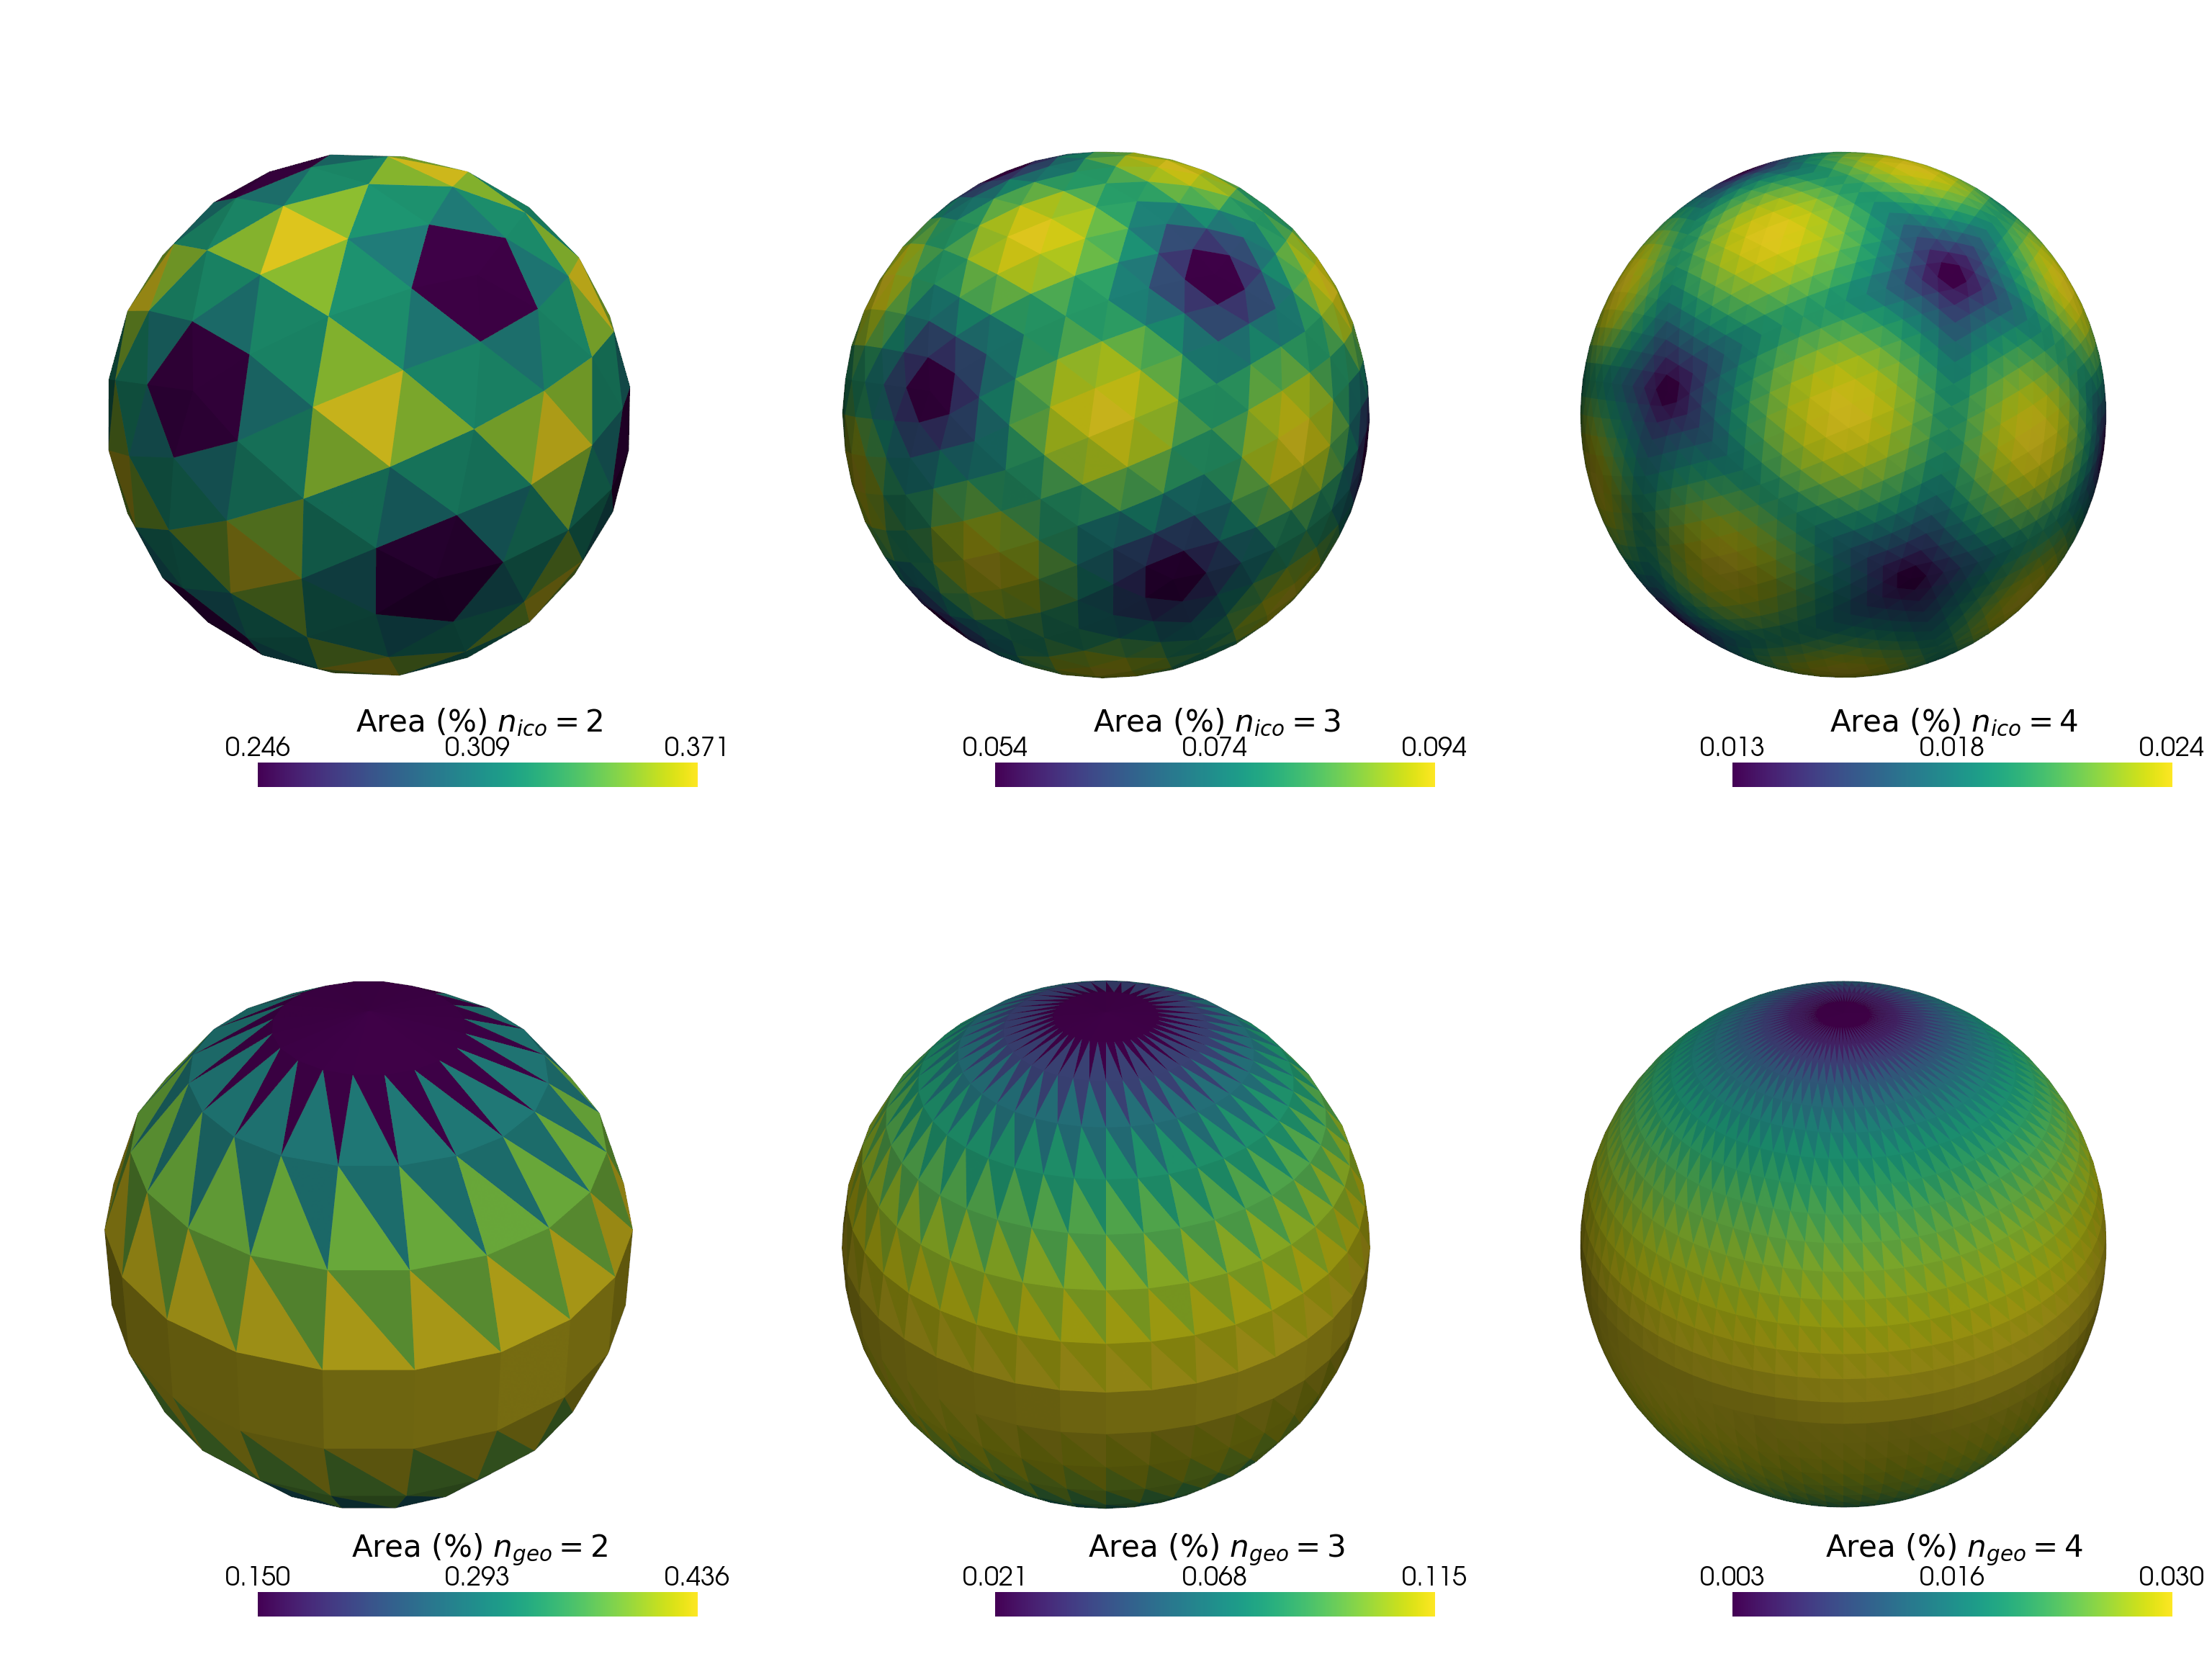

In [5]:
# # ! Plot
pl = pv.Plotter(shape=(2, 3), border=False, image_scale=3)
pickNs = [2, 3, 4]
# Top row: Icosphere
for col, nsub in enumerate(pickNs):
    mesh = pv.Icosphere(radius=1.0, nsub=nsub)
    mesh = mesh.compute_cell_sizes()
    areas = mesh['Area']
    scalar_name = f'ico_area_n{nsub}'
    mesh[scalar_name] = 100 * areas / areas.sum()
    pl.subplot(0, col)
    pl.add_mesh(mesh, scalars=scalar_name, cmap='viridis',
                scalar_bar_args=dict(title=f'Area (%) $n_{{ico}}={nsub}$', 
                                     title_font_size=14, label_font_size=12,
                                     n_labels=3, position_y=0.05, fmt='%.3f'))
    pl.camera.zoom(1.25)
# Bottom row: Geographic grid
for col, nsub in enumerate(pickNs):
    mesh = pv.Sphere(radius=1.0,
                     theta_resolution=Lon_Res[nsub],
                     phi_resolution=Lat_Res[nsub])
    mesh = mesh.compute_cell_sizes()
    areas = mesh['Area']
    scalar_name = f'geo_area_n{nsub}'
    mesh[scalar_name] = 100 * areas / areas.sum()
    pl.subplot(1, col)
    pl.add_mesh(mesh, scalars=scalar_name, cmap='viridis',
                scalar_bar_args=dict(title=f'Area (%) $n_{{geo}}={nsub}$', 
                                     title_font_size=14, label_font_size=12,
                                     n_labels=3, position_y=0.05, fmt='%.3f'))
    pl.camera.zoom(1.25)
pl.show()
# pl.screenshot("Sphere_Polyhedron.png");

In [6]:
# # ! End time
print("="*80)
print(f"End time: [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]")
print("="*80)

End time: [2026-04-25 18:20:50]
